<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [ ]:
!pip install -U \
  sentence-transformers \
  faiss-cpu \
  langchain \
  langchain-community \
  langchain-core \
  langchain-huggingface \
  huggingface_hub \
  langchain-text-splitters

In [2]:
import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain_core.documents import Document as LangchainDocument
from sentence_transformers import SentenceTransformer
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline
from sklearn.ensemble import IsolationForest

pd.set_option("display.max_colwidth", None)

## Загрузка данных (4 балла)

In [ ]:
drive = False
if drive: 
    url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
    output = 'file.csv'
    
    gdown.download(url, output, quiet=False)
    
    data = pd.read_csv(output)
else:
    data = pd.read_csv("/kaggle/input/datasets/vasilijkrukovskij/wikitexts/data.csv")
print(data.shape)
print(data.columns)
data.head()

Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [ ]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image
    
def show_sample(data):
    row = data.sample(1).iloc[0]
    image = get_image(row['image'])
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(image)
    ax.axis('off')
    
    title = f"{row['Name']} — {row['City']}"
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Description:\n{row['description']}\n")
    print(f"EN txt:\n{row['en_txt']}")

show_sample(data)

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [ ]:
# 1. CLEAN TEXT
# Чистка на наличие данных
data["description"] = data["description"].fillna("").astype(str).str.strip()
data["en_txt"] = data["en_txt"].fillna("").astype(str).str.strip()
data = data[
    (data["description"].str.len() > 0) &
    (data["en_txt"].str.len() > 0) &
    (data["Lon"].notna()) &
    (data["Lat"].notna()) &
    (data["WikiData"].notna())
]


# 2. BUILD STRUCTURED TEXT (для всех строк)
def build_text(row):
    return f"""Name: {row['Name']}
City: {row['City']}
Description:
{row['description']}
Visual description:
{row['en_txt']}""".strip()

data["text"] = data.apply(build_text, axis=1)


# 3. OUTLIER FILTER по text
embedder = HuggingFaceEmbeddings(
    model_name="intfloat/multilingual-e5-base"
)

def batch_embed(embedder, texts, batch_size=64):
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        all_embeddings.extend(embedder.embed_documents(batch))
    return np.array(all_embeddings)
    
X = batch_embed(embedder, data["text"].tolist())
iso = IsolationForest(contamination=0.05, random_state=42)
data["is_outlier"] = iso.fit_predict(X)

n_outliers = (data["is_outlier"] == -1).sum()
n_total = len(data)
print(f"Outliers: {n_outliers} / {n_total} ({n_outliers/n_total*100:.1f}%)")

df_outliers = data[data["is_outlier"] == -1][["Name", "City", "description", "en_txt"]].sample(min(5, n_outliers))
for _, row in df_outliers.iterrows():
    print(f"\n{'='*60}")
    print(f"Name: {row['Name']} | City: {row['City']}")
    print(f"Description: {row['description'][:300]}")
    print(f"En_txt: {row['en_txt'][:300]}")

df_clean = data[data["is_outlier"] == 1].copy()

# 4. SELECT BEST ROW PER (City, Name)
def select_best(group):
    scores = group["description"].str.len()
    scores += group["en_txt"].str.len() * 0.5
    return group.loc[scores.idxmax()]

df_final = df_clean.groupby(["City", "Name"], group_keys=False).apply(select_best).reset_index(drop=True)

# 5. CREATE RAG DOCUMENTS
documents = []
for _, row in df_final.iterrows():
    doc = LangchainDocument(
        page_content=row["text"],
        metadata={
            "city": row["City"],
            "name": row["Name"],
            "lat": row["Lat"],
            "lon": row["Lon"],
            "image": row["image"],
            "wikidata": row["WikiData"],
        }
    )
    documents.append(doc)

# 6. RESULT CHECK
print("Total clean samples (grouped):", len(df_final))
df_final["text_len"] = df_final["text"].str.len()
plt.hist(df_final["text_len"], bins=25)
plt.title("Text length distribution (clean samples)")
plt.show()

Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

In [ ]:
# your code here
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import CrossEncoder

# ~400 символов - максимум в данных, это не много чтобы воспользоваться чанкированием, поэтому используем dummy chunking
# Также, данные уже разделены по смыслу, что является ключевой задачей чанкирования 
splitter = RecursiveCharacterTextSplitter(
  chunk_size=1000000,
  chunk_overlap=0
)

def chanking(splitter, docs):
    chunks_with_metadata = []
    
    for doc in documents:  
        split_texts = splitter.split_text(doc.page_content)
        for text_chunk in split_texts:
            new_doc = LangchainDocument(
                page_content=text_chunk,
                metadata=doc.metadata.copy()
            )
            chunks_with_metadata.append(new_doc)
    
    print(f"Создано чанков: {len(chunks_with_metadata)}")
    return chunks_with_metadata

chunks = chanking(splitter, documents)

# embedder для поисковых механизмов RAG (мультиязычный)
embedder = HuggingFaceEmbeddings(
    model_name="intfloat/multilingual-e5-base"
)
# Отсортировал не с помощью ragatouille, а с помощью CrossEncoder,
# т.к. проблемы с установкой библиотек и их зависимостями
reranker = CrossEncoder("cross-encoder/mmarco-mMiniLMv2-L12-H384-v1")

def create_vs(docs_with_metadata, embedder):
    vectorstore = FAISS.from_documents(
        docs_with_metadata,
        embedder
    )
    return vectorstore

vectorstore = create_vs(chunks, embedder)


def retrieve(vectorstore, query, k=10):
  return vectorstore.similarity_search(query, k=k)

def rerank(reranker, query, docs):
  pairs = [(query, d.page_content) for d in docs]
  scores = reranker.predict(pairs)
  ranked = sorted(zip(docs, scores), key=lambda x: x[1], reverse=True)
  return ranked

def generate_answer(question, context, gen_tokenizer, gen_model):
    messages = [{
        "role": "user",
        "content": (
            f"Answer the question based on the context below.\n\n"
            f"Context:\n{context}\n\n"
            f"Question: {question}\n\n"
            f"Answer concisely in 1-2 sentences."
        )
    }]
    prompt = gen_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = gen_tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = gen_model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,
            pad_token_id=gen_tokenizer.eos_token_id
        )
    generated = outputs[0][inputs["input_ids"].shape[1]:]
    return gen_tokenizer.decode(generated, skip_special_tokens=True).strip()


def rag(query, reranker, vectorstore, gen_tokenizer, gen_model, top_k=30, top_n=5, threshold_p=0.7):
  '''RAG - метод работы с LLM, путём подбора контекста из БД
    для максимизации правильного answer на query пользователя'''

  docs = retrieve(vectorstore, query, top_k)
  ranked_results = rerank(reranker, query, docs)
  # конкатенация в отсортированном порядке
  filtered_docs = [doc.page_content for doc, score in ranked_results if score >= threshold_p]
  full_context_str = "\n".join(filtered_docs)
  answer = generate_answer(query, full_context_str, gen_tokenizer, gen_model)
  return answer, filtered_docs[:top_n]


model_name = "Qwen/Qwen2.5-3B-Instruct"
gen_tokenizer = AutoTokenizer.from_pretrained(model_name)
gen_model = AutoModelForCausalLM.from_pretrained(
    model_name, torch_dtype=torch.float16
).to("cuda")
gen_model.eval()

query = "Where is the Museum of Dolls and Children's Books 'Land of Wonders' located?"
rag(query, reranker, vectorstore, gen_tokenizer, gen_model, top_k=25, top_n=5, threshold_p=0.7)

Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [ ]:
# your code here
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

chunk_embeddings = embedder.embed_documents([doc.page_content for doc in chunks])

pca = PCA(n_components=2)
emb_pca = pca.fit_transform(chunk_embeddings)

plt.figure(figsize=(8,6))
plt.scatter(emb_pca[:,0], emb_pca[:,1], s=5)
plt.title("PCA of embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

import umap

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

emb_umap = umap_model.fit_transform(chunk_embeddings)

plt.figure(figsize=(8,6))
plt.scatter(emb_umap[:,0], emb_umap[:,1], s=5)
plt.title("UMAP of embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

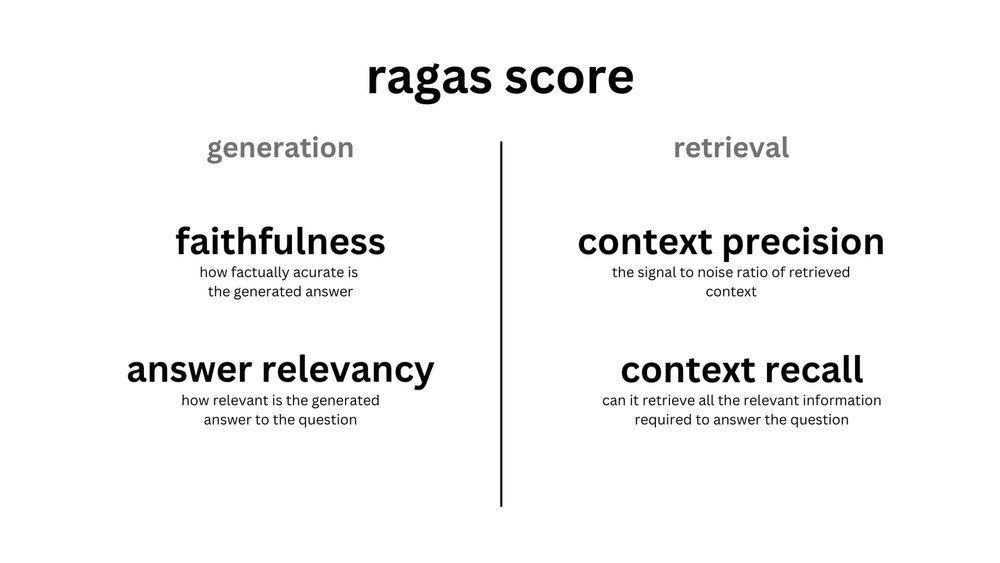

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [ ]:
def data_preprocess(df_final, tokenizer, model, top_k=25, top_n=4, threshold_p=0.7):
    
    QUESTION_TYPES = {
        "location": "where this place is geographically (city)",
        "description": "what this place or object is",
        "name": "what the official name of this place is",
        "image": "what can be seen at this place visually",
    }
    def extract_answer(row, qtype):
      return {
          "location": row["City"],
          "description": row["description"],
          "name": row["Name"],
          "image": row["en_txt"],
      }[qtype]

    def make_question(text, qtype):
        messages = [{
            "role": "user",
            "content": (
                f"Generate ONE short question about this text focusing on: {qtype}.\n"
                f"The question should sound like a real user searching for information.\n"
                f"Reply with the question only.\n\nText:\n{text}"
            )
        }]
        prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=64,
                do_sample=True,
                temperature=0.8,
                top_p=0.9,
                pad_token_id=tokenizer.eos_token_id
            )
        generated = outputs[0][inputs["input_ids"].shape[1]:]
        return tokenizer.decode(generated, skip_special_tokens=True).strip()

    rows = []
    for _, row in tqdm(df_final.iterrows(), total=len(df_final), desc="Generating questions and answers"):
        text = row["text"]
        for qtype, qfocus in QUESTION_TYPES.items():
            question = make_question(text, qfocus)
            answer, context_list = rag(question, reranker, vectorstore, gen_tokenizer, gen_model, top_k=top_k, top_n=top_n, threshold_p=threshold_p)
            rows.append({
                "question": question,
                "contexts": context_list,
                "ground_truth": extract_answer(row, qtype),
                "answer": answer
            })
    return pd.DataFrame(rows)
    
# В датасет формируются 4 тематических вопроса на сэмпл, правильные ответы из структурированного context, 
# найденный ретривером контекст, а также ответ генератора.
# Для ускорения теста возьмём 100 сэмплов -> 400 вопросов
train_dataset = data_preprocess(df_final.sample(100, random_state=42), gen_tokenizer, gen_model, 
                                top_k=25, top_n=4, threshold_p=0.7)
train_dataset.head()

In [26]:
def answer_relevancy(questions, answers, gen_tokenizer, gen_model, n=3):
    scores = []
    q_embs_all = np.array(embedder.embed_documents(questions))

    for i, (question, answer) in tqdm(enumerate(zip(questions, answers)), total=len(answers)):
        # генерируем n вопросов из ответа
        generated_questions = []
        for _ in range(n):
            messages = [{"role": "user", "content": 
                f"Generate a question that this answer is responding to.\nAnswer: {answer}\nQuestion:"}]
            prompt = gen_tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            )
            inputs = gen_tokenizer(prompt, return_tensors="pt").to("cuda")
            with torch.no_grad():
                out = gen_model.generate(**inputs, max_new_tokens=64,
                                         pad_token_id=gen_tokenizer.eos_token_id)
            generated = out[0][inputs["input_ids"].shape[1]:]
            generated_questions.append(gen_tokenizer.decode(generated, skip_special_tokens=True).strip())

        # среднее сходство с оригинальным вопросом
        gen_embs = np.array(embedder.embed_documents(generated_questions))
        q_emb = q_embs_all[i]
        sims = [np.dot(q_emb, g) / (np.linalg.norm(q_emb) * np.linalg.norm(g))
                for g in gen_embs]
        scores.append(float(np.mean(sims)))

    return scores


def faithfulness(answers, contexts, gen_tokenizer, gen_model):
    scores = []
    for answer, context in tqdm(zip(answers, contexts), total=len(answers)):
        # просим LLM разбить ответ на утверждения
        messages = [{"role": "user", "content":
            f"Break this answer into individual factual claims, one per line."
            f"Be lenient with synonyms and rephrasing."
            f"Answer: {answer}\nClaims:"}]
        prompt = gen_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = gen_tokenizer(prompt, return_tensors="pt").to("cuda")
        with torch.no_grad():
            out = gen_model.generate(**inputs, max_new_tokens=128, pad_token_id=gen_tokenizer.eos_token_id)
        generated = out[0][inputs["input_ids"].shape[1]:]
        claims_text = gen_tokenizer.decode(generated, skip_special_tokens=True).strip()
        claims = [c.strip("- ").strip() for c in claims_text.split("\n") if c.strip()]

        if not claims:
            scores.append(0.0)
            continue

        # для каждого утверждения проверяем — есть ли оно в контексте
        supported = 0
        for claim in claims:
            messages = [{"role": "user", "content":
                f"Does the following context support this claim? Answer only Yes or No.\n\nContext: {context}\n\nClaim: {claim}\n\nAnswer:"}]
            prompt = gen_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            inputs = gen_tokenizer(prompt, return_tensors="pt").to("cuda")
            with torch.no_grad():
                out = gen_model.generate(**inputs, max_new_tokens=5, pad_token_id=gen_tokenizer.eos_token_id)
            generated = out[0][inputs["input_ids"].shape[1]:]
            verdict = gen_tokenizer.decode(generated, skip_special_tokens=True).strip().lower()
            if "yes" in verdict:
                supported += 1

        scores.append(supported / len(claims))

    return scores


def context_recall(ground_truths, contexts, gen_tokenizer, gen_model):
    scores = []
    for gt, ctx_list in tqdm(zip(ground_truths, contexts), total=len(ground_truths)):
        context = "\n".join(ctx_list) if isinstance(ctx_list, list) else ctx_list

        # разбиваем ground truth на утверждения
        messages = [{"role": "user", "content":
            f"Break this text into individual factual claims, one per line." 
            f"Be lenient with synonyms and rephrasing."
            f"Text: {gt}\nClaims:"}]
        prompt = gen_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = gen_tokenizer(prompt, return_tensors="pt").to("cuda")
        with torch.no_grad():
            out = gen_model.generate(**inputs, max_new_tokens=128, pad_token_id=gen_tokenizer.eos_token_id)
        claims_text = gen_tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
        claims = [c.strip("- ").strip() for c in claims_text.split("\n") if c.strip()]

        if not claims:
            scores.append(0.0)
            continue

        # проверяем каждое утверждение
        supported = 0
        for claim in claims:
            messages = [{"role": "user", "content":
                f"Does the following context support this claim? Answer only Yes or No.\n\nContext: {context}\n\nClaim: {claim}\n\nAnswer:"}]
            prompt = gen_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            inputs = gen_tokenizer(prompt, return_tensors="pt").to("cuda")
            with torch.no_grad():
                out = gen_model.generate(**inputs, max_new_tokens=5, pad_token_id=gen_tokenizer.eos_token_id)
            verdict = gen_tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip().lower()
            if "yes" in verdict:
                supported += 1

        scores.append(supported / len(claims))

    return scores


def context_precision(questions, ground_truths, contexts, gen_tokenizer, gen_model):
    scores = []
    for question, gt, ctx_list in tqdm(zip(questions, ground_truths, contexts), total=len(questions)):
        if isinstance(ctx_list, str):
            ctx_list = [ctx_list]

        verdicts = []
        for chunk in ctx_list:
            messages = [{"role": "user", "content":
                f"Is the following context useful for answering the question?\n\n"
                f"Question: {question}\n"
                f"Ground truth answer: {gt}\n"
                f"Context: {chunk}\n\n"
                f"Answer only Yes or No"}]
            prompt = gen_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            inputs = gen_tokenizer(prompt, return_tensors="pt").to("cuda")
            with torch.no_grad():
                out = gen_model.generate(**inputs, max_new_tokens=5, pad_token_id=gen_tokenizer.eos_token_id)
            verdict = gen_tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip().lower()
            verdicts.append(1 if "yes" in verdict else 0)

        # average precision@k — учитывает порядок
        if sum(verdicts) == 0:
            scores.append(0.0)
            continue

        precisions = []
        for k, v in enumerate(verdicts, start=1):
            if v == 1:
                precisions.append(sum(verdicts[:k]) / k)
        scores.append(np.mean(precisions))

    return scores


def evaluate_rag(results_df, embedder, vectorstore, reranker, gen_tokenizer, gen_model):

    print("answer_relevancy computing...")
    results_df["answer_relevancy"] = answer_relevancy(
        results_df["question"].tolist(),
        results_df["answer"].tolist(),
        gen_tokenizer, gen_model
    )
    print("context_recall computing...")
    results_df["context_recall"] = context_recall(
        results_df["ground_truth"].tolist(),
        results_df["contexts"].tolist(),
        gen_tokenizer, gen_model
    )
    print("context_precision computing...")
    results_df["context_precision"] = context_precision(
        results_df["question"].tolist(),
        results_df["ground_truth"].tolist(),
        results_df["contexts"].tolist(),
        gen_tokenizer, gen_model
    )
    print("faithfulness computing...")
    results_df["faithfulness"] = faithfulness(
        results_df["answer"].tolist(),
        results_df["contexts"].tolist(),
        gen_tokenizer, gen_model
    )
    print("\n=== RAG Evaluation Results ===")
    print(f"Answer Relevancy:   {results_df['answer_relevancy'].mean():.3f}")
    print(f"Context Recall:     {results_df['context_recall'].mean():.3f}")
    print(f"Context Precision:  {results_df['context_precision'].mean():.3f}")
    print(f"Faithfulness:       {results_df['faithfulness'].mean():.3f}")
    return results_df

# Протестируйте ваш RAG (3 балла)

In [ ]:
results = evaluate_rag(train_dataset.sample(100, random_state=42), embedder, vectorstore, reranker, 
                       gen_tokenizer, gen_model)

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [ ]:
# your code here
# Реализовал выше